# 🛍️ Customer Segmentation Using K-Means Clustering

---

| Field | Details |
|---|---|
| **Project** | Customer Segmentation |
| **Dataset** | Mall Customers Dataset (Kaggle) |
| **Method** | K-Means Clustering |
| **Tools** | Python, Scikit-learn, Seaborn, Plotly |
| **Author** | Lavkumar Jha |
| **Task** | SYNENT Internship — Task 2 |

---

The idea behind this project is simple: a mall has 200 customers and wants to figure out how to market differently to different kinds of people. Instead of sending the same email to everyone, can we find natural groups in the data?

That's what clustering is for. No labels needed — just let the algorithm find structure on its own.

## 1. Problem Statement

The marketing team of a shopping mall wants to understand their customers better. They have collected basic data — age, gender, annual income, and a spending score (assigned by the mall based on purchase history).

**Goal:** Group customers into distinct segments so that each group can receive a targeted marketing strategy.

**Type:** Unsupervised Machine Learning — there are no pre-existing labels. The algorithm has to discover groups by itself.

**Why K-Means?**  
K-Means is easy to understand, fast, and gives interpretable results. For a dataset this size, it works well. The main requirement is that we decide how many clusters (K) we want — which we'll figure out using the Elbow Method.

## 2. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Libraries loaded successfully.
Pandas  : 2.2.2
NumPy   : 2.0.2


## 3. Load Dataset

In [6]:
# Load the CSV — make sure Mall_Customers.csv is inside the dataset/ folder
df = pd.read_csv('Mall_Customers.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
import os

os.makedirs("images", exist_ok=True)

## 4. Initial Data Inspection

Before doing anything, I want to know what I'm working with — data types, missing values, and basic statistics.

In [8]:
print('=== Data Types & Non-Null Counts ===')
print(df.info())

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [9]:
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [10]:
# Check for missing values — this dataset is known to be clean but always verify
print('Missing values per column:')
print(df.isnull().sum())
print()

print(f'Duplicate rows: {df.duplicated().sum()}')
print()

print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0

Unique values per column:
  CustomerID: 200
  Gender: 2
  Age: 51
  Annual Income (k$): 64
  Spending Score (1-100): 84


**Observation:** No missing values, no duplicates. The dataset is clean. Gender is the only categorical column — everything else is numeric. CustomerID is just an identifier and won't be used for analysis.

## 5. Data Cleaning

The dataset is already quite clean. A few small things to fix:
- Rename columns to remove spaces and special characters
- Drop CustomerID (it's just a row number)
- Encode Gender numerically (for use in analysis and optional clustering)

In [11]:
# Rename for easier access
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Encode gender — needed for any numeric analysis
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Drop CustomerID — no analytical value
df.drop(columns=['CustomerID'], inplace=True)

print('Cleaned dataset columns:', list(df.columns))
print(f'Shape: {df.shape}')
df.head()

Cleaned dataset columns: ['Gender', 'Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']
Shape: (200, 5)


,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,1
3,Female,23,16,77,1
4,Female,31,17,40,1


## 6. Exploratory Data Analysis (EDA)

EDA is the part where you actually get to understand the data before building any model. I want to look at distributions, check for patterns, and figure out which features are worth using for clustering.

### 6.1 Gender Distribution

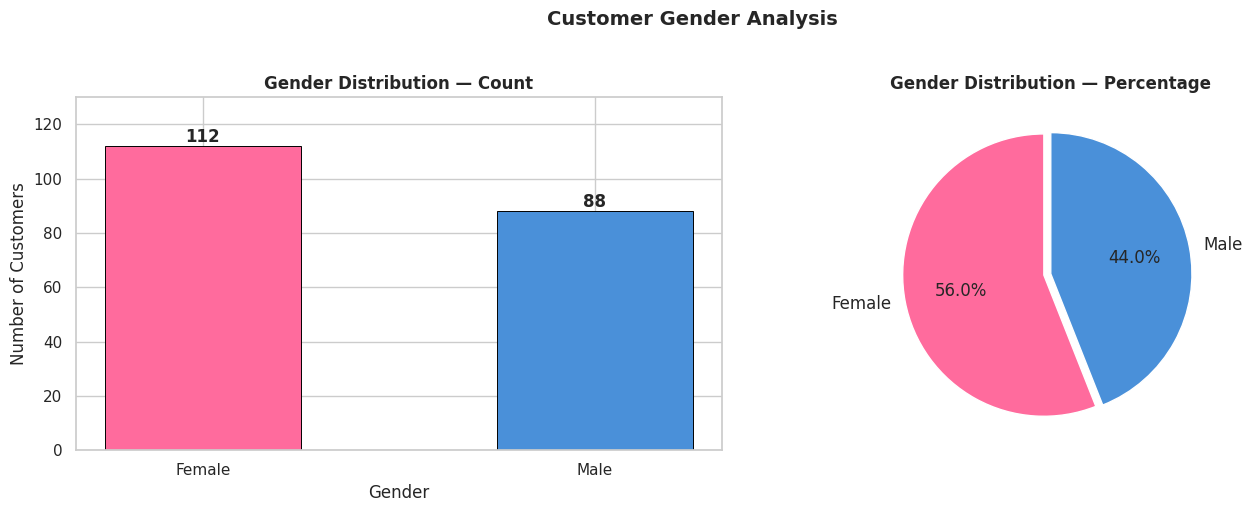

Female: 112 (56.0%)
Male  : 88 (44.0%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['Gender'].value_counts()
colors_g = ['#FF6B9D', '#4A90D9']

# Bar chart
axes[0].bar(gender_counts.index, gender_counts.values,
            color=colors_g, edgecolor='black', linewidth=0.7, width=0.5)
axes[0].set_title('Gender Distribution — Count', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 130)
for i, (label, val) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[0].text(i, val + 1.5, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values,
            labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=colors_g,
            startangle=90,
            explode=(0.05, 0),
            textprops={'fontsize': 12})
axes[1].set_title('Gender Distribution — Percentage', fontweight='bold')

plt.suptitle('Customer Gender Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Female: {gender_counts['Female']} ({gender_counts['Female']/len(df)*100:.1f}%)")
print(f"Male  : {gender_counts['Male']} ({gender_counts['Male']/len(df)*100:.1f}%)")

**Observation:** More female customers (56%) than male (44%). The gap isn't huge, but it's worth keeping in mind for campaign planning.

### 6.2 Age, Income, and Spending Score Distributions

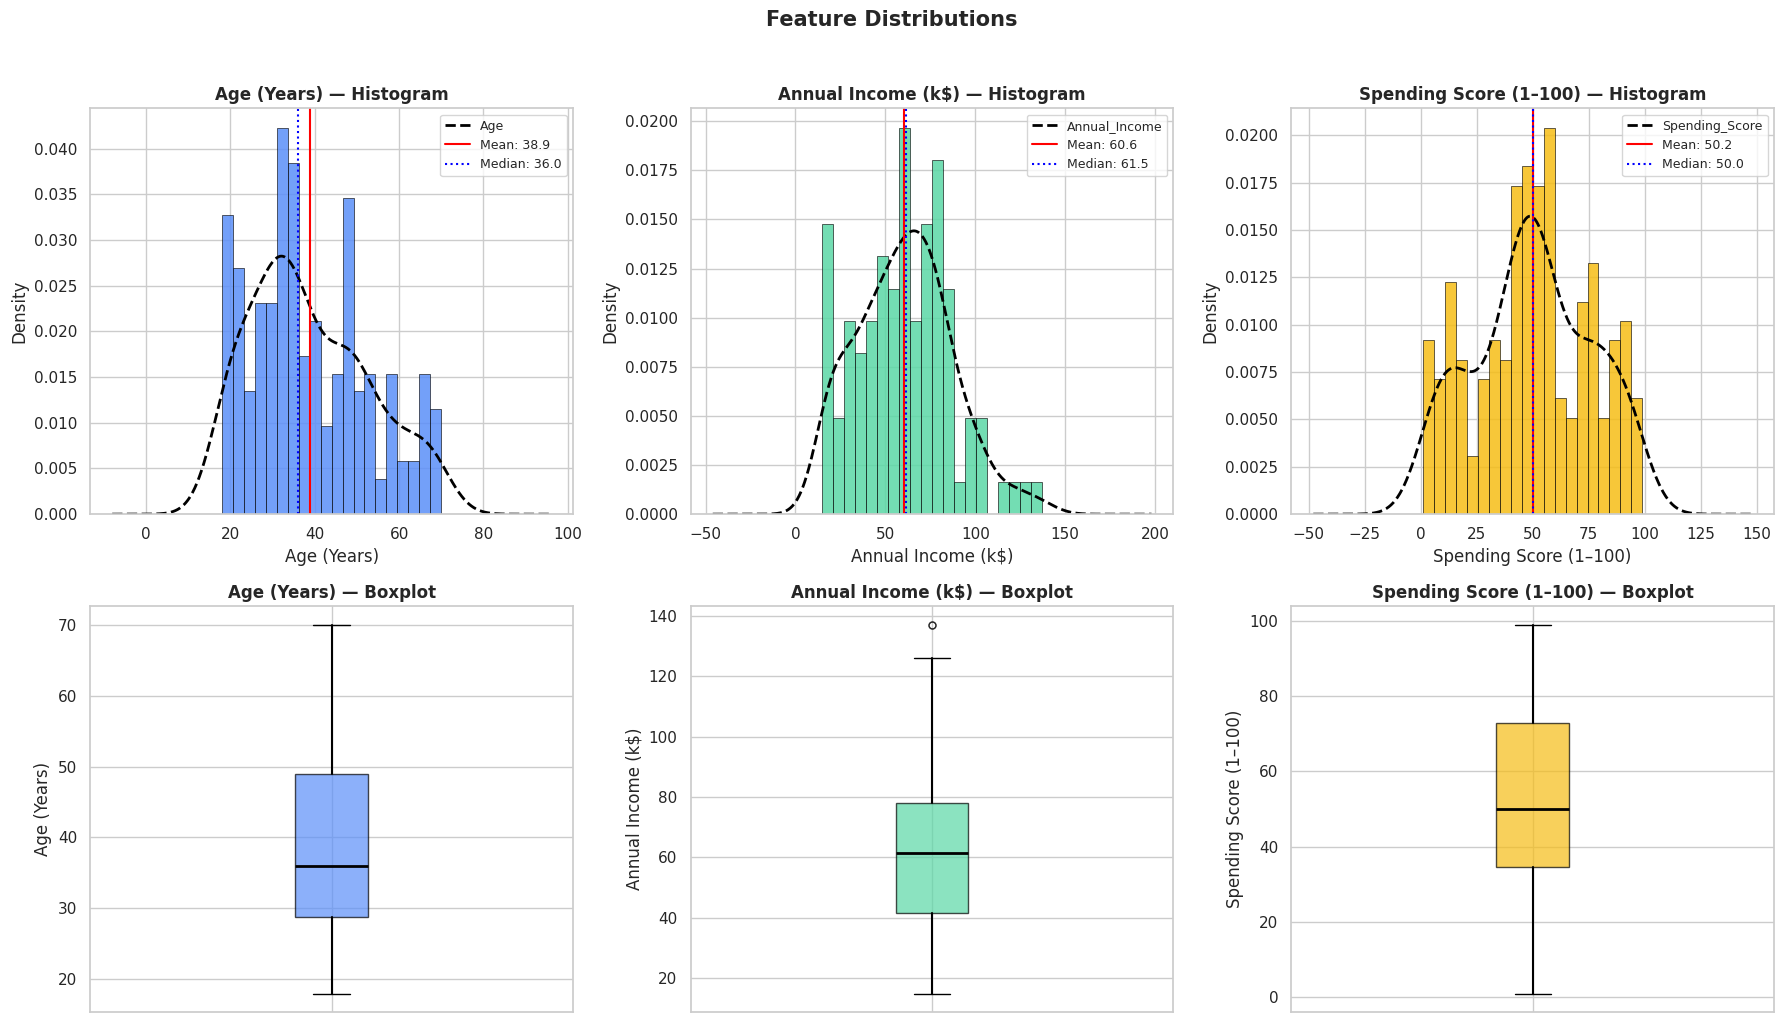

          Age  Annual_Income  Spending_Score
count  200.00         200.00          200.00
mean    38.85          60.56           50.20
std     13.97          26.26           25.82
min     18.00          15.00            1.00
25%     28.75          41.50           34.75
50%     36.00          61.50           50.00
75%     49.00          78.00           73.00
max     70.00         137.00           99.00


In [13]:
features   = ['Age', 'Annual_Income', 'Spending_Score']
feat_labels = ['Age (Years)', 'Annual Income (k$)', 'Spending Score (1–100)']
colors_f   = ['#5B8FF9', '#5AD8A6', '#F6BD16']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (feat, label, color) in enumerate(zip(features, feat_labels, colors_f)):

    # Histogram with KDE
    axes[0, i].hist(df[feat], bins=20, color=color,
                    edgecolor='black', linewidth=0.5, alpha=0.85, density=True)
    df[feat].plot(kind='kde', ax=axes[0, i],
                  color='black', linewidth=2, linestyle='--')
    axes[0, i].axvline(df[feat].mean(), color='red', linewidth=1.5,
                       label=f'Mean: {df[feat].mean():.1f}')
    axes[0, i].axvline(df[feat].median(), color='blue', linewidth=1.5,
                       linestyle=':', label=f'Median: {df[feat].median():.1f}')
    axes[0, i].set_title(f'{label} — Histogram', fontweight='bold')
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Density')
    axes[0, i].legend(fontsize=9)

    # Box plot
    axes[1, i].boxplot(df[feat], patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.7),
                       medianprops=dict(color='black', linewidth=2),
                       whiskerprops=dict(linewidth=1.5),
                       flierprops=dict(marker='o', color='red',
                                       markersize=5, alpha=0.6))
    axes[1, i].set_title(f'{label} — Boxplot', fontweight='bold')
    axes[1, i].set_ylabel(label)
    axes[1, i].set_xticklabels([''])

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[features].describe().round(2))

**Observation:**
- Age is slightly right-skewed — younger customers are more common.
- Annual Income looks fairly symmetric with a mean around \$60k.
- Spending Score is spread almost evenly across the full range (1–99), which hints that there might be distinct groups at the extremes. I didn't expect this initially — I thought spending would cluster toward the middle.

### 6.3 Scatter Plot Relationships

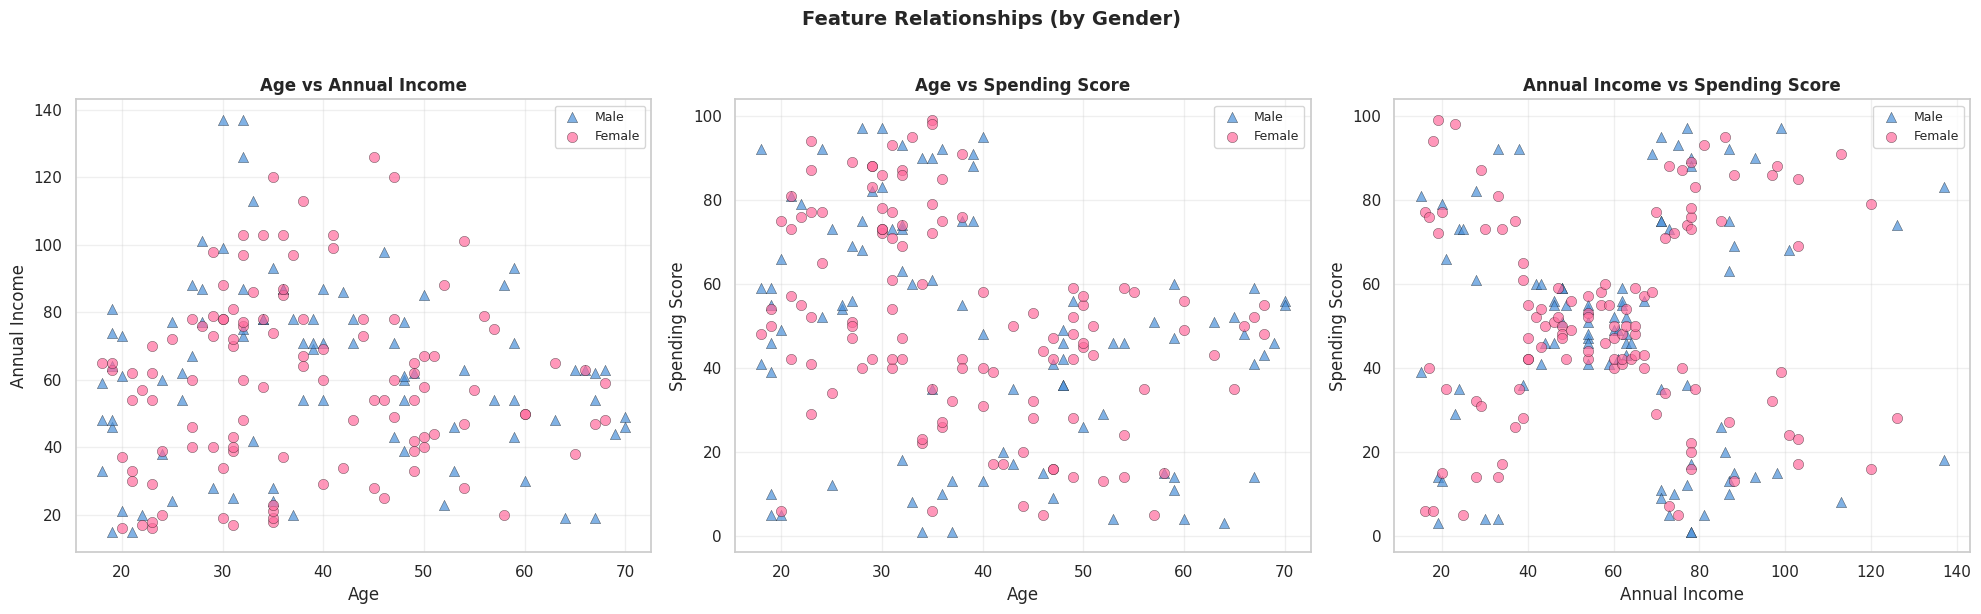

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scatter_pairs = [
    ('Age', 'Annual_Income', 'Age vs Annual Income'),
    ('Age', 'Spending_Score', 'Age vs Spending Score'),
    ('Annual_Income', 'Spending_Score', 'Annual Income vs Spending Score')
]

gender_styles = {
    'Male':   {'color': '#4A90D9', 'marker': '^'},
    'Female': {'color': '#FF6B9D', 'marker': 'o'}
}

for ax, (x, y, title) in zip(axes, scatter_pairs):
    for gender, style in gender_styles.items():
        mask = df['Gender'] == gender
        ax.scatter(df[mask][x], df[mask][y],
                   c=style['color'], marker=style['marker'],
                   alpha=0.7, s=55, edgecolors='black',
                   linewidth=0.3, label=gender)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(x.replace('_', ' '))
    ax.set_ylabel(y.replace('_', ' '))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Relationships (by Gender)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/scatter_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
- The income vs spending plot is the most revealing. You can already see roughly 5 natural groups by eye — before running any algorithm.
- The income and spending relationship was weaker than I initially assumed. You'd think higher earners spend more, but the scatter shows no clear trend.
- Younger customers tend to have higher spending scores, which makes sense — they might prioritize experiences over savings.

### 6.4 Correlation Heatmap

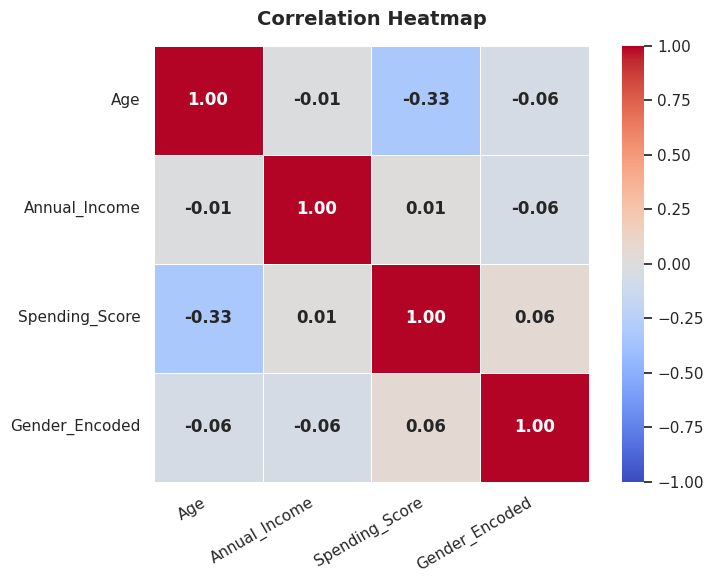

Correlation with Spending_Score:
Age              -0.327227
Annual_Income     0.009903
Gender_Encoded    0.058109
Spending_Score    1.000000
Name: Spending_Score, dtype: float64


In [15]:
numeric_cols  = ['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']
corr_matrix   = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Spending_Score:')
print(corr_matrix['Spending_Score'].sort_values())

**Observation:**
- `Annual_Income` and `Spending_Score` have almost zero correlation (≈ 0.01). This confirms they are independent — which is exactly what makes them useful together for clustering.
- `Age` has a mild negative correlation with `Spending_Score` (≈ -0.33). Older customers tend to spend slightly less.
- Gender has very weak correlations with all features — so splitting analysis by gender alone won't reveal much.

### 6.5 Pairplot

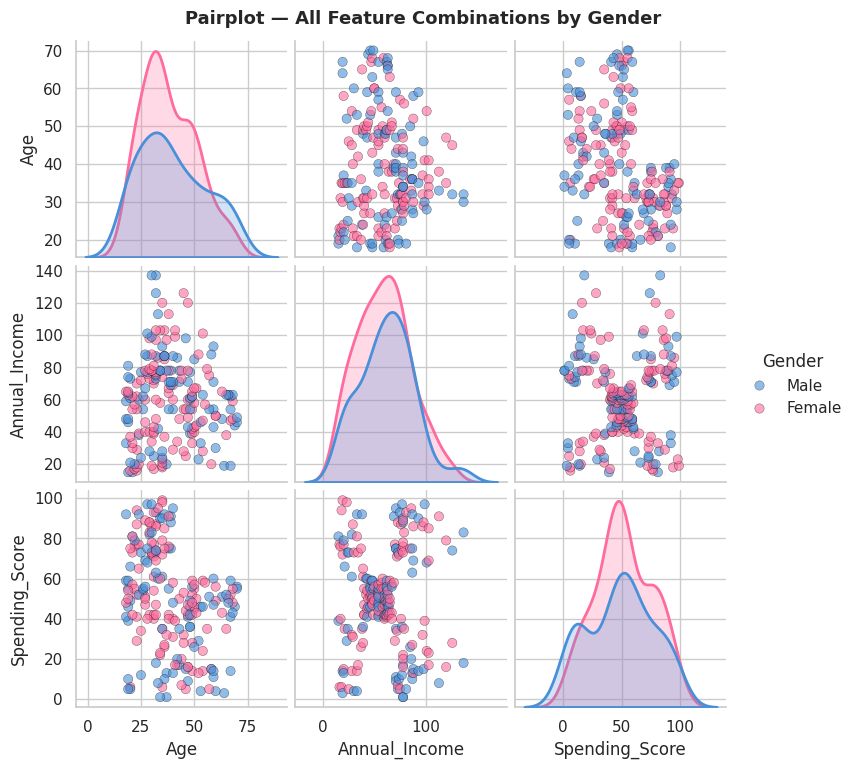

Pairplot saved.


In [16]:
pairplot_df = df[['Age', 'Annual_Income', 'Spending_Score', 'Gender']].copy()

g = sns.pairplot(
    pairplot_df,
    hue='Gender',
    palette={'Male': '#4A90D9', 'Female': '#FF6B9D'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 45, 'edgecolor': 'black', 'linewidth': 0.3},
    diag_kws={'linewidth': 2}
)
g.fig.suptitle('Pairplot — All Feature Combinations by Gender',
               fontsize=13, fontweight='bold', y=1.02)

plt.savefig('images/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Pairplot saved.')

**Observation:** The `Annual_Income` vs `Spending_Score` subplot shows the clearest groupings — the 5-cluster structure is visible here even without running the algorithm. The pairplot also confirms that male and female customers overlap heavily across all feature dimensions.

## 7. Feature Selection

Based on the EDA, `Annual_Income` and `Spending_Score` are the most informative features for clustering — they're independent, business-relevant, and visually show natural groupings. I'll use these two for the primary 2D clustering and add `Age` for the 3D visualization.

In [17]:
# Features for 2D clustering (main analysis)
X_2d = df[['Annual_Income', 'Spending_Score']].copy()

# Features for 3D visualization (adds Age as a third dimension)
X_3d = df[['Age', 'Annual_Income', 'Spending_Score']].copy()

print('2D features shape:', X_2d.shape)
print('3D features shape:', X_3d.shape)
print()
print('Feature selection rationale:')
print('  Annual_Income  → economic capacity of the customer')
print('  Spending_Score → actual behavior at the mall')
print('  Age            → added for 3D view — useful context')
print('  Gender         → weak correlations, not used for clustering')
print('  CustomerID     → identifier only, dropped earlier')

2D features shape: (200, 2)
3D features shape: (200, 3)

Feature selection rationale:
  Annual_Income  → economic capacity of the customer
  Spending_Score → actual behavior at the mall
  Age            → added for 3D view — useful context
  Gender         → weak correlations, not used for clustering
  CustomerID     → identifier only, dropped earlier


## 8. Feature Scaling

K-Means uses Euclidean distance to assign points to clusters. If one feature has much larger values than another, it will dominate the distance calculation — not because it's more important, but just because its numbers are bigger.

Annual Income ranges up to 137k. Spending Score only goes to 99. Without scaling, income would drive almost all clustering decisions. `StandardScaler` fixes this by centering each feature at 0 with a standard deviation of 1.

In [18]:
scaler = StandardScaler()

# Fit and transform 2D features
X_2d_scaled = scaler.fit_transform(X_2d)
X_2d_scaled_df = pd.DataFrame(X_2d_scaled,
                               columns=['Annual_Income_scaled',
                                        'Spending_Score_scaled'])

# Fit and transform 3D features (separate scaler instance)
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print('Before scaling:')
print(X_2d.describe().round(2))
print()
print('After scaling (mean ≈ 0, std ≈ 1):')
print(X_2d_scaled_df.describe().round(3))

Before scaling:
       Annual_Income  Spending_Score
count         200.00          200.00
mean           60.56           50.20
std            26.26           25.82
min            15.00            1.00
25%            41.50           34.75
50%            61.50           50.00
75%            78.00           73.00
max           137.00           99.00

After scaling (mean ≈ 0, std ≈ 1):
       Annual_Income_scaled  Spending_Score_scaled
count               200.000                200.000
mean                 -0.000                 -0.000
std                   1.003                  1.003
min                  -1.739                 -1.910
25%                  -0.728                 -0.600
50%                   0.036                 -0.008
75%                   0.666                  0.885
max                   2.918                  1.894


## 9. Finding Optimal K — Elbow Method + Silhouette Score

K-Means requires us to specify K upfront. The Elbow Method helps find the right value by plotting WCSS (Within-Cluster Sum of Squares) against K. WCSS is the total squared distance between each point and its cluster center — lower means tighter clusters.

As K increases, WCSS always drops. The "elbow" is the point where it stops dropping sharply — after that, adding more clusters gives diminishing returns.

I also compute the Silhouette Score as a second check. It measures how well each point fits its own cluster versus the nearest neighboring cluster. Range: -1 to 1. Higher is better.

In [19]:
k_range          = range(1, 11)
wcss             = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++',
                n_init=10, max_iter=300, random_state=42)
    km.fit(X_2d_scaled)
    wcss.append(km.inertia_)

    # Silhouette only valid for k >= 2
    if k >= 2:
        score = silhouette_score(X_2d_scaled, km.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None)

print('K  |   WCSS    | Silhouette')
print('-' * 35)
for i, k in enumerate(k_range):
    sil = f'{silhouette_scores[i]:.4f}' if silhouette_scores[i] else '  N/A'
    print(f'{k:2d} | {wcss[i]:9.2f} | {sil}')

K  |   WCSS    | Silhouette
-----------------------------------
 1 |    400.00 |   N/A
 2 |    269.69 | 0.3213
 3 |    157.70 | 0.4666
 4 |    108.92 | 0.4939
 5 |     65.57 | 0.5547
 6 |     55.06 | 0.5399
 7 |     44.86 | 0.5281
 8 |     37.23 | 0.4552
 9 |     32.39 | 0.4571
10 |     29.98 | 0.4432


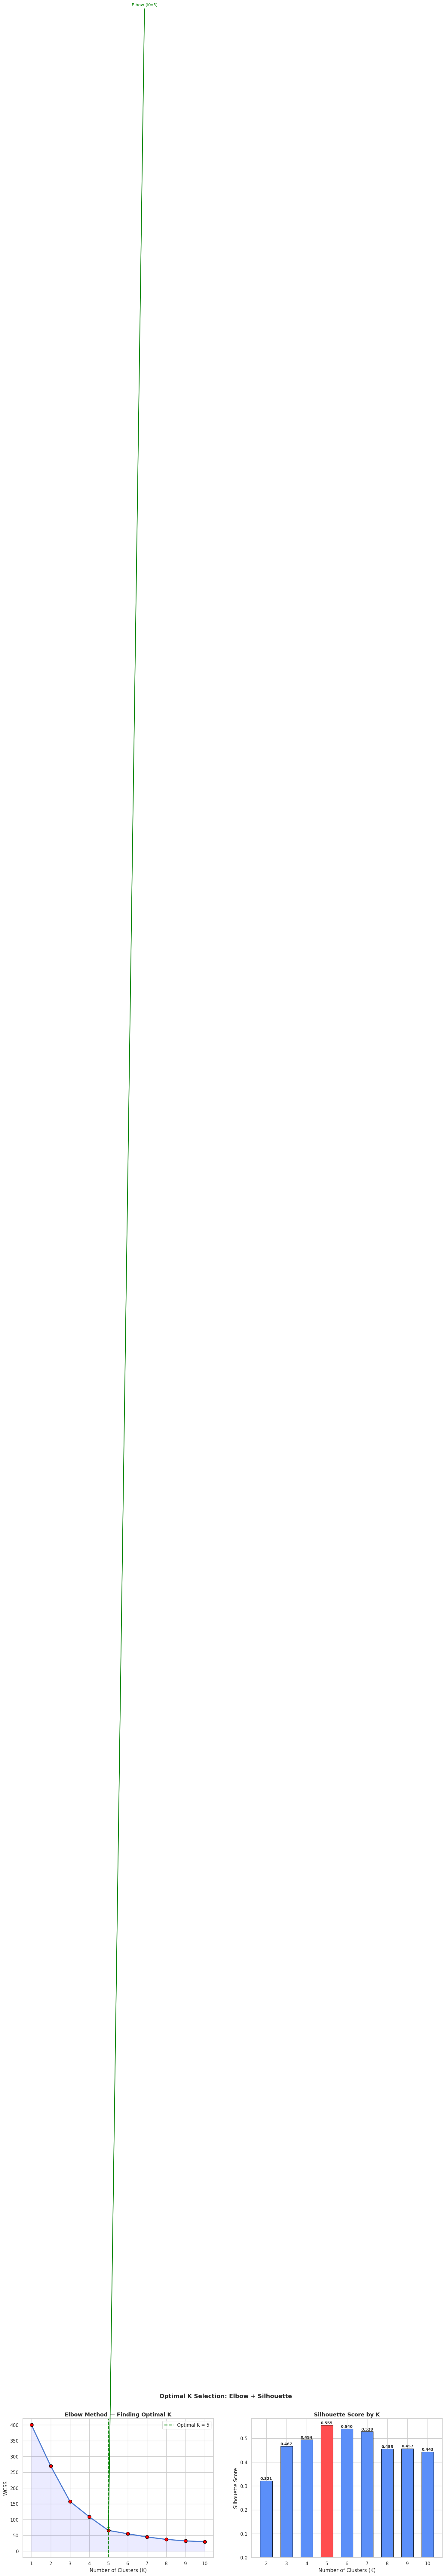

Elbow method suggests  : K = 5
Best silhouette score  : K = 5 (0.5547)
Chosen K               : 5


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Elbow Curve ---
axes[0].plot(list(k_range), wcss,
             'bo-', linewidth=2.5, markersize=8,
             markerfacecolor='red', markeredgecolor='black')
axes[0].axvline(x=5, color='green', linestyle='--',
                linewidth=2, label='Optimal K = 5')
axes[0].fill_between(list(k_range), wcss, alpha=0.08, color='blue')
axes[0].set_title('Elbow Method — Finding Optimal K',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=11)
axes[0].annotate('Elbow (K=5)',
                 xy=(5, wcss[4]),
                 xytext=(6.2, wcss[4] + 8000),
                 fontsize=10, color='green',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.8))

# --- Silhouette Scores ---
sil_k   = list(range(2, 11))
sil_vals = [s for s in silhouette_scores if s is not None]

bar_colors = ['#FF4D4F' if k == 5 else '#5B8FF9' for k in sil_k]
bars = axes[1].bar(sil_k, sil_vals,
                   color=bar_colors, edgecolor='black',
                   linewidth=0.8, width=0.6)
axes[1].set_title('Silhouette Score by K',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(sil_k)
for bar, val in zip(bars, sil_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 val + 0.005, f'{val:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Optimal K Selection: Elbow + Silhouette',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = sil_k[sil_vals.index(max(sil_vals))]
print(f'Elbow method suggests  : K = 5')
print(f'Best silhouette score  : K = {best_k} ({max(sil_vals):.4f})')
print(f'Chosen K               : 5')

**Observation:**
At first I expected the elbow at K=3 or K=4, but the curve bends most sharply at K=5. The Silhouette Score also peaks around K=5, confirming this choice. Beyond 5, adding more clusters gives minimal improvement in tightness.

## 10. K-Means Clustering (K = 5)

Now that we've confirmed K=5, we train the final model.

**K-Means algorithm in plain language:**
1. Place 5 random starting points (centroids) in the feature space
2. Assign every customer to the nearest centroid
3. Move each centroid to the average of its assigned customers
4. Repeat until nothing changes

We use `k-means++` initialization, which spreads the starting centroids out intelligently rather than placing them randomly — this leads to faster convergence and more stable results.

In [21]:
OPTIMAL_K = 5

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',   # smarter initialization vs random
    n_init=10,          # run 10 times, keep best result
    max_iter=300,
    random_state=42     # for reproducibility
)
kmeans.fit(X_2d_scaled)

# Attach cluster labels back to the dataframe
df['Cluster'] = kmeans.labels_

print(f'Model trained. WCSS (inertia): {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X_2d_scaled, kmeans.labels_):.4f}')
print()
print('Customers per cluster:')
cluster_counts = df['Cluster'].value_counts().sort_index()
for c, count in cluster_counts.items():
    print(f'  Cluster {c}: {count} customers')

Model trained. WCSS (inertia): 65.57
Silhouette Score: 0.5547

Customers per cluster:
  Cluster 0: 81 customers
  Cluster 1: 39 customers
  Cluster 2: 22 customers
  Cluster 3: 35 customers
  Cluster 4: 23 customers


## 11. Cluster Visualizations

### 11.1 2D Cluster Plot

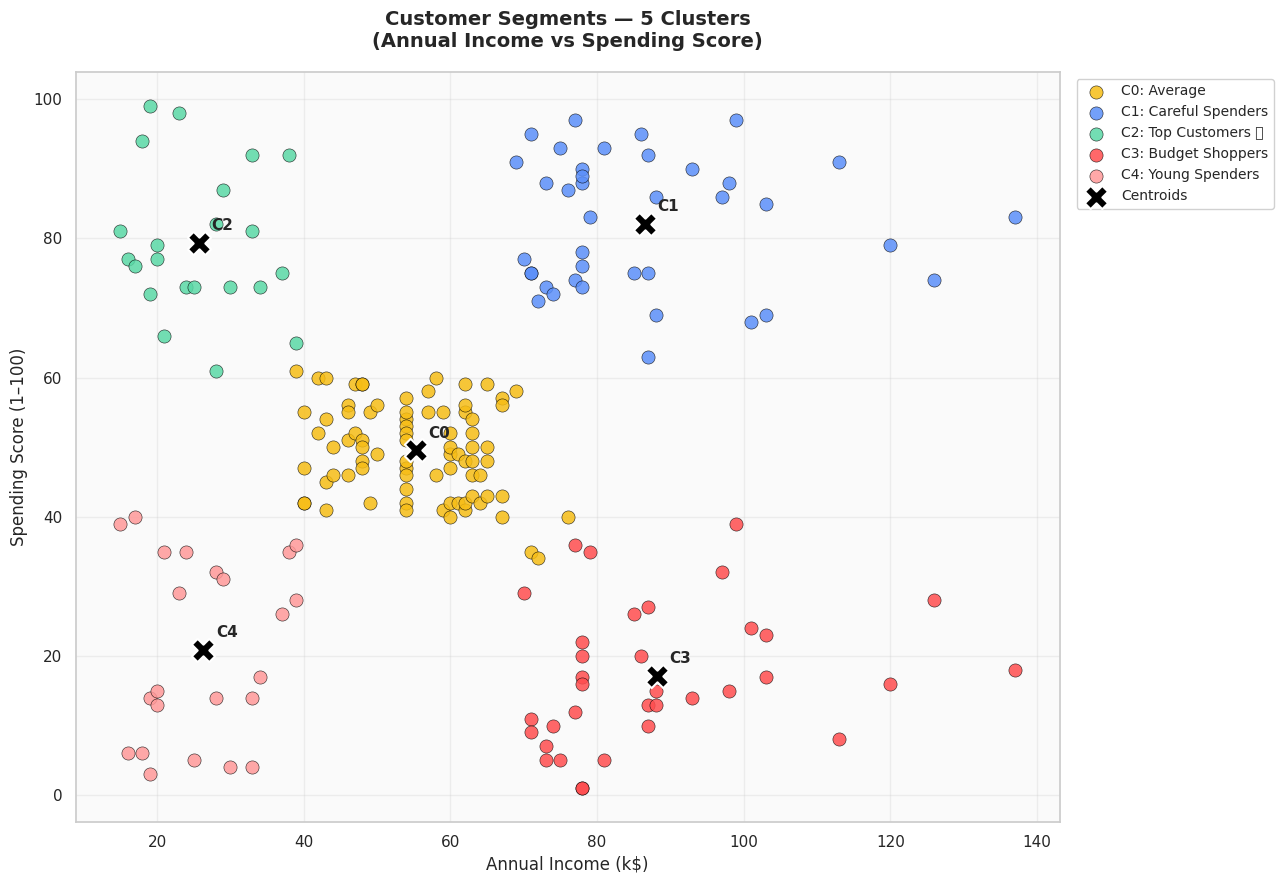

2D cluster plot saved.


In [22]:
# Map cluster IDs to descriptive labels — assigned after visual inspection
# The labels depend on which cluster lands where after fitting
# (K-Means doesn't guarantee the same cluster ID ordering every run,
# but random_state=42 makes it reproducible)

cluster_colors = {
    0: '#F6BD16',
    1: '#5B8FF9',
    2: '#5AD8A6',
    3: '#FF4D4F',
    4: '#FF9999'
}

cluster_labels = {
    0: 'C0: Average',
    1: 'C1: Careful Spenders',
    2: 'C2: Top Customers ⭐',
    3: 'C3: Budget Shoppers',
    4: 'C4: Young Spenders'
}

# Inverse transform centroids back to original scale for annotation
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(13, 9))

for c in range(OPTIMAL_K):
    mask = df['Cluster'] == c
    ax.scatter(
        df[mask]['Annual_Income'],
        df[mask]['Spending_Score'],
        c=cluster_colors[c],
        label=cluster_labels[c],
        s=90, alpha=0.85,
        edgecolors='black', linewidth=0.4
    )

# Plot centroids
ax.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    s=280, c='black', marker='X', zorder=5,
    label='Centroids', edgecolors='white', linewidth=1.5
)

# Label centroids
for i, (cx, cy) in enumerate(centroids_orig):
    ax.annotate(f'C{i}', (cx, cy),
                textcoords='offset points',
                xytext=(9, 9),
                fontsize=11, fontweight='bold')

ax.set_title('Customer Segments — 5 Clusters\n(Annual Income vs Spending Score)',
             fontsize=14, fontweight='bold', pad=18)
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1–100)', fontsize=12)
ax.legend(loc='upper left', fontsize=10,
          framealpha=0.9, bbox_to_anchor=(1.01, 1))
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('images/cluster_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('2D cluster plot saved.')

**Observation:** The 5 clusters are clearly separated with minimal overlap. Centroids sit near the center of each group. The separation on the Income-Spending plane is quite clean — this validates the choice of these two features for clustering.

### 11.2 Interactive 3D Cluster Plot

In [23]:
# Run KMeans on 3D features for the 3D visualization
kmeans_3d = KMeans(n_clusters=5, init='k-means++',
                   n_init=10, random_state=42)
kmeans_3d.fit(X_3d_scaled)
df['Cluster_3D'] = kmeans_3d.labels_
df['Cluster_3D_Name'] = df['Cluster_3D'].map(
    {i: f'Cluster {i}' for i in range(5)})

fig_3d = px.scatter_3d(
    df,
    x='Annual_Income',
    y='Spending_Score',
    z='Age',
    color='Cluster_3D_Name',
    symbol='Gender',
    hover_data=['Age', 'Annual_Income', 'Spending_Score', 'Gender'],
    title='3D Customer Segmentation: Income × Spending Score × Age',
    labels={
        'Annual_Income': 'Annual Income (k$)',
        'Spending_Score': 'Spending Score',
        'Age': 'Age',
        'Cluster_3D_Name': 'Cluster'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.85,
    height=650
)
fig_3d.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color='black')))
fig_3d.update_layout(
    scene=dict(
        xaxis_title='Annual Income (k$)',
        yaxis_title='Spending Score',
        zaxis_title='Age'
    ),
    legend_title_text='Cluster'
)
fig_3d.show()
print('Rotate the 3D plot to explore how clusters separate across Age too.')

Rotate the 3D plot to explore how clusters separate across Age too.


### 11.3 Cluster Feature Boxplots

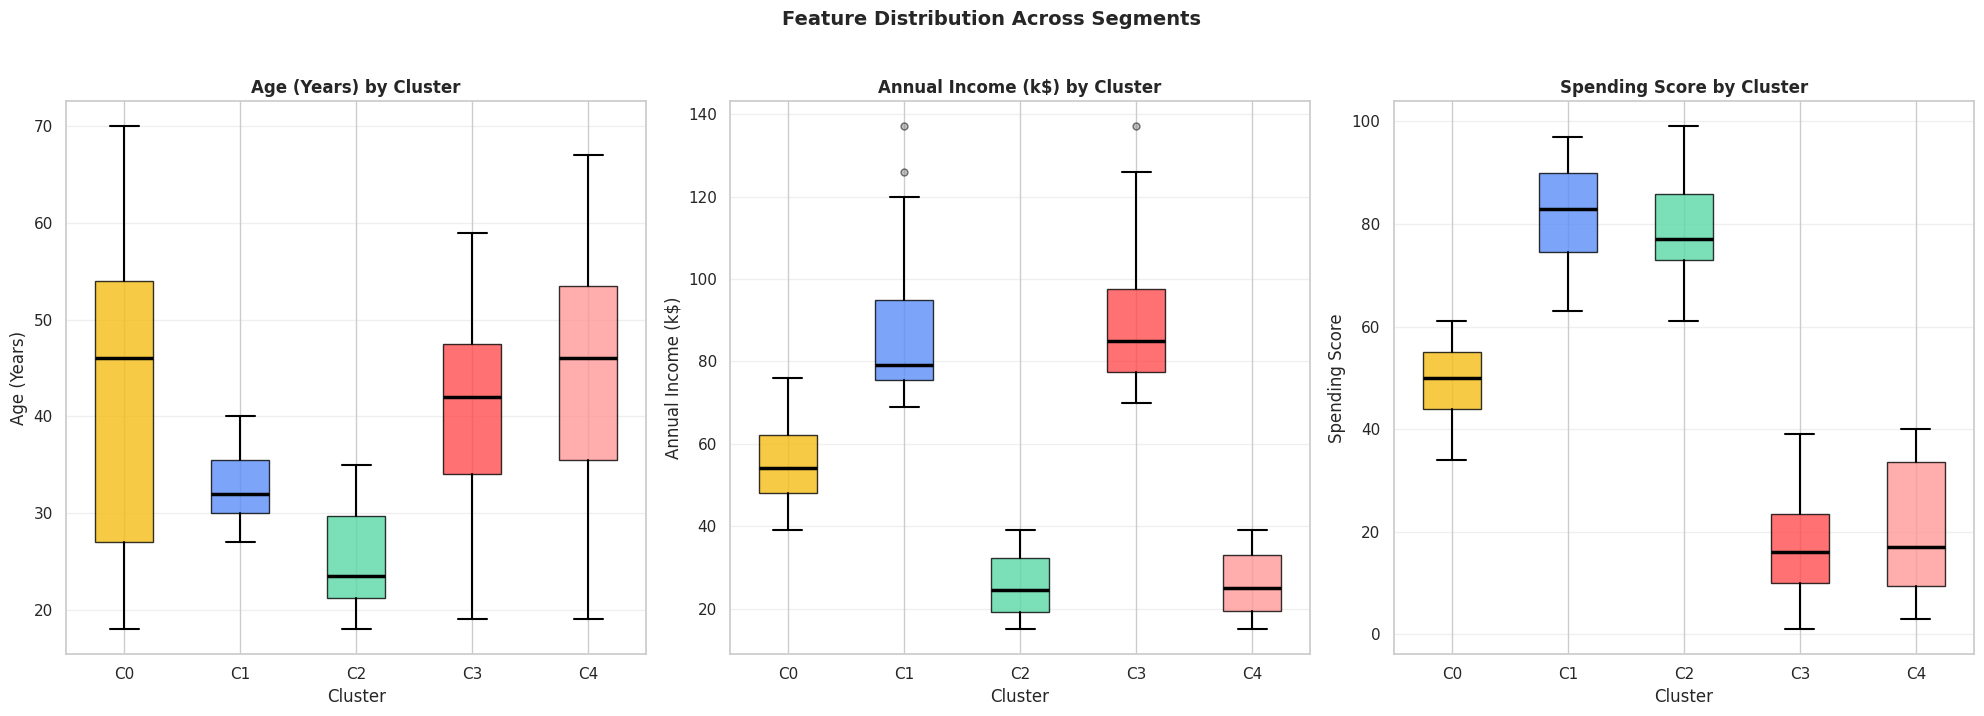

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
box_features = ['Age', 'Annual_Income', 'Spending_Score']
box_labels   = ['Age (Years)', 'Annual Income (k$)', 'Spending Score']
box_colors   = [cluster_colors[i] for i in range(5)]

for ax, feat, label in zip(axes, box_features, box_labels):
    data_per_cluster = [df[df['Cluster'] == c][feat].values for c in range(5)]
    bp = ax.boxplot(
        data_per_cluster,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=5,
                        markerfacecolor='gray', alpha=0.5)
    )
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(f'{label} by Cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(label)
    ax.set_xticklabels([f'C{i}' for i in range(5)])
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distribution Across Segments',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cluster Profiling

Now that we have 5 clusters, let's describe each one in concrete terms — average age, income, spending score, and gender breakdown.

In [25]:
profile = df.groupby('Cluster').agg(
    Count        = ('Cluster', 'count'),
    Avg_Age      = ('Age', 'mean'),
    Avg_Income   = ('Annual_Income', 'mean'),
    Avg_Spending = ('Spending_Score', 'mean'),
    Female_Pct   = ('Gender_Encoded', lambda x: f'{x.mean()*100:.0f}%')
).round(1)

profile.index = [f'Cluster {i}' for i in profile.index]

print('=== Cluster Profile Summary ===')
display(profile)

=== Cluster Profile Summary ===


,Count,Avg_Age,Avg_Income,Avg_Spending,Female_Pct
Cluster 0,81,42.7,55.3,49.5,59%
Cluster 1,39,32.7,86.5,82.1,54%
Cluster 2,22,25.3,25.7,79.4,59%
Cluster 3,35,41.1,88.2,17.1,46%
Cluster 4,23,45.2,26.3,20.9,61%


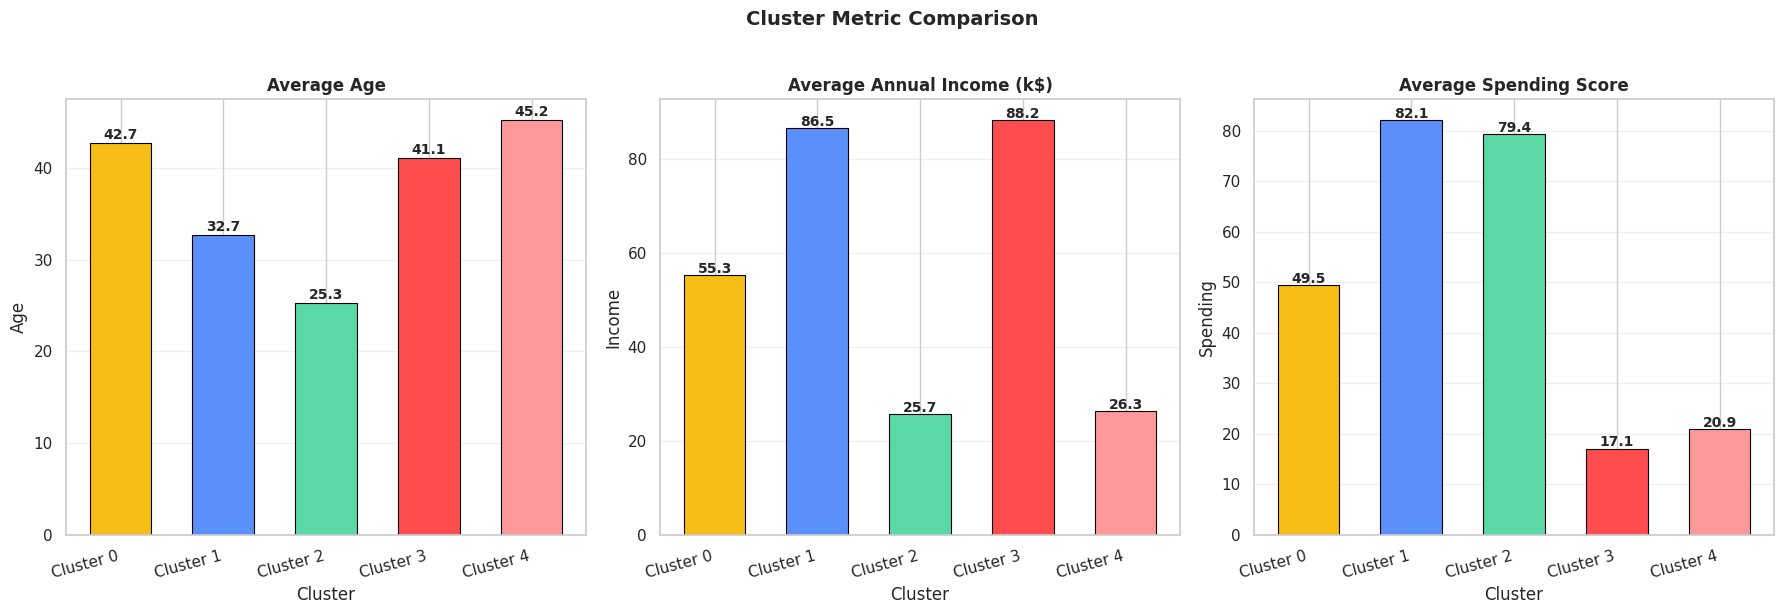

In [26]:
# Bar chart comparison of core metrics per cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Avg_Age', 'Avg_Income', 'Avg_Spending']
titles  = ['Average Age', 'Average Annual Income (k$)', 'Average Spending Score']
bar_c   = [cluster_colors[i] for i in range(5)]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(
        profile.index,
        profile[metric],
        color=bar_c,
        edgecolor='black', linewidth=0.8, width=0.6
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric.replace('Avg_', ''))
    ax.set_xticklabels(profile.index, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.4,
                f'{h:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Cluster Metric Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

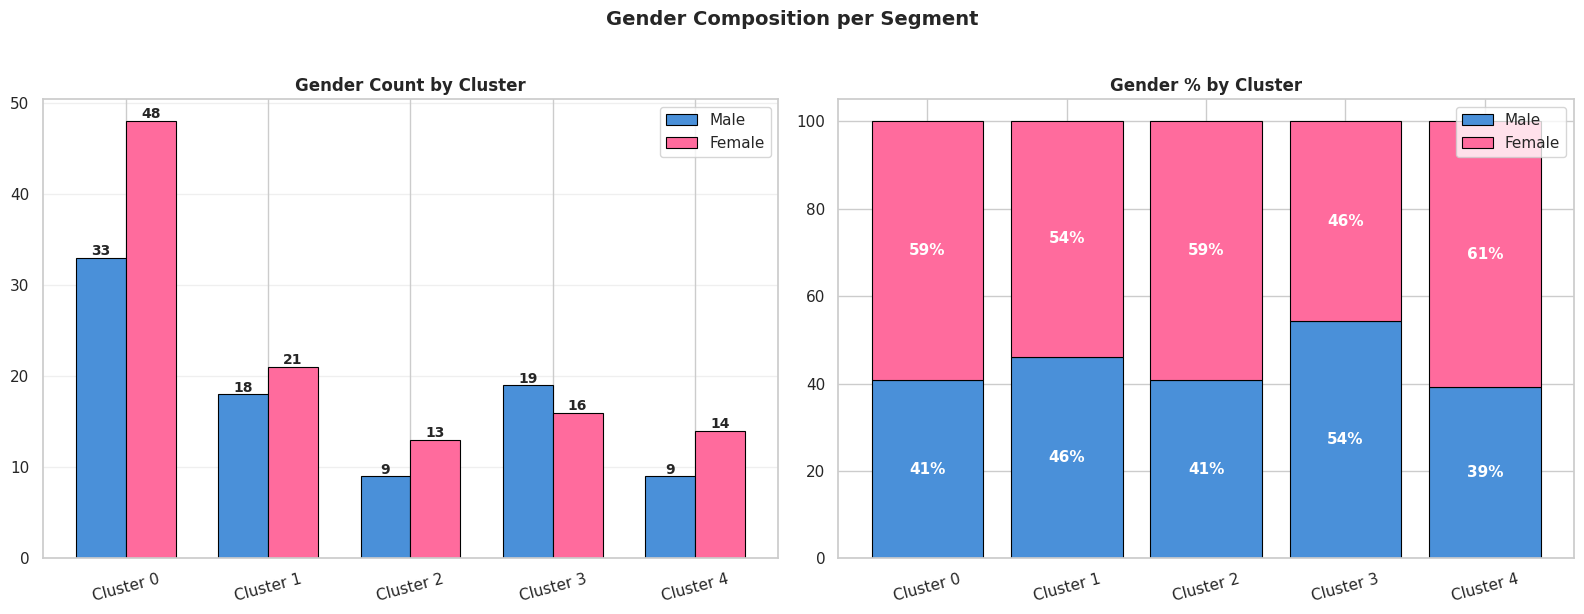

In [27]:
# Gender split per cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gender_cluster = df.groupby(['Cluster', 'Gender']).size().unstack(fill_value=0)
gender_cluster.index = [f'Cluster {i}' for i in gender_cluster.index]

x = np.arange(len(gender_cluster))
w = 0.35

b_m = axes[0].bar(x - w/2, gender_cluster['Male'],   w,
                  label='Male',   color='#4A90D9', edgecolor='black', lw=0.8)
b_f = axes[0].bar(x + w/2, gender_cluster['Female'], w,
                  label='Female', color='#FF6B9D', edgecolor='black', lw=0.8)

for bar in list(b_m) + list(b_f):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.3,
                 str(int(bar.get_height())),
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Gender Count by Cluster', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_cluster.index, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Stacked percentage
gender_pct = gender_cluster.div(gender_cluster.sum(axis=1), axis=0) * 100
axes[1].bar(gender_cluster.index, gender_pct['Male'],
            label='Male', color='#4A90D9', edgecolor='black', lw=0.8)
axes[1].bar(gender_cluster.index, gender_pct['Female'],
            bottom=gender_pct['Male'],
            label='Female', color='#FF6B9D', edgecolor='black', lw=0.8)

for i, (mp, fp) in enumerate(zip(gender_pct['Male'], gender_pct['Female'])):
    axes[1].text(i, mp/2,       f'{mp:.0f}%', ha='center', va='center',
                 fontsize=11, fontweight='bold', color='white')
    axes[1].text(i, mp + fp/2,  f'{fp:.0f}%', ha='center', va='center',
                 fontsize=11, fontweight='bold', color='white')

axes[1].set_title('Gender % by Cluster', fontweight='bold')
axes[1].set_xticklabels(gender_cluster.index, rotation=15)
axes[1].legend()

plt.suptitle('Gender Composition per Segment',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/gender_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

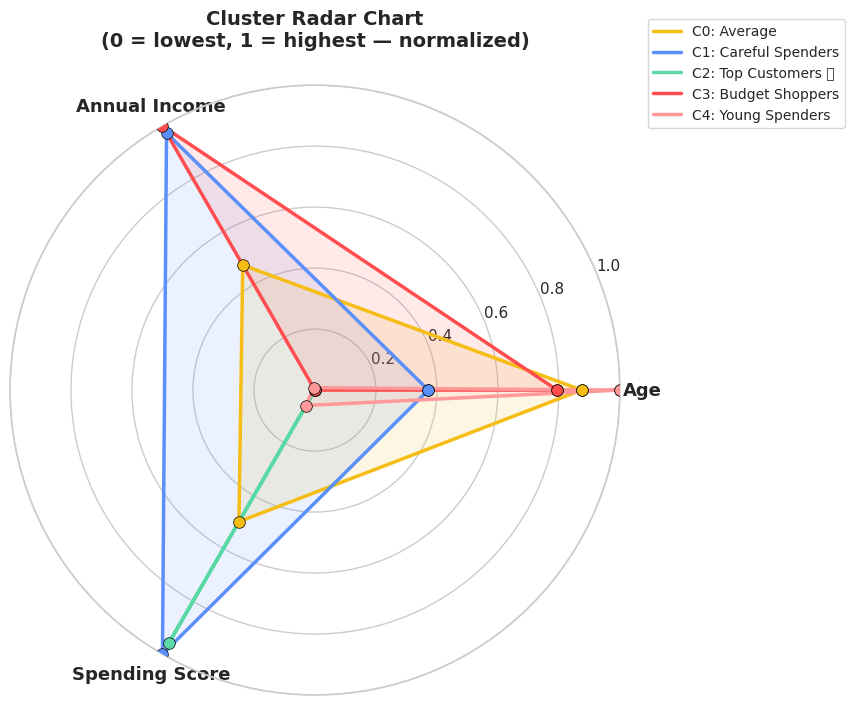

In [28]:
# Radar chart — compare all clusters across 3 normalized dimensions
cluster_means = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean()
normalized    = (cluster_means - cluster_means.min()) / \
                (cluster_means.max() - cluster_means.min())

categories = ['Age', 'Annual Income', 'Spending Score']
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

radar_colors = ['#F6BD16', '#5B8FF9', '#5AD8A6', '#FF4D4F', '#FF9999']
radar_labels = ['C0: Average', 'C1: Careful Spenders',
                'C2: Top Customers ⭐', 'C3: Budget Shoppers',
                'C4: Young Spenders']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for idx in range(5):
    vals  = normalized.iloc[idx].tolist() + [normalized.iloc[idx].tolist()[0]]
    ax.plot(angles, vals, color=radar_colors[idx], linewidth=2.5, label=radar_labels[idx])
    ax.fill(angles, vals, color=radar_colors[idx], alpha=0.12)
    ax.scatter(angles, vals, color=radar_colors[idx], s=70, zorder=5,
               edgecolors='black', linewidth=0.5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Cluster Radar Chart\n(0 = lowest, 1 = highest — normalized)',
             fontsize=14, fontweight='bold', pad=28)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig('images/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Business Recommendations

The clusters are only useful if they translate into concrete actions. Here's what each segment means in practice.

In [29]:
recommendations = {
    'Cluster 0 — Average Customers': {
        'Profile'    : 'Mid income (~$55k), mid spending (~50), age ~43',
        'Size'       : '~81 customers — the largest group',
        'Behavior'   : 'Balanced across all metrics — not extreme in any direction',
        'Strategies' : [
            'Loyalty reward programs — points, vouchers, membership tiers',
            'Seasonal promotions to increase visit frequency',
            'Bundle deals to nudge up average transaction size',
            'Email campaigns based on past purchase history'
        ]
    },
    'Cluster 1 — Careful Spenders (High Income, Low Spending)': {
        'Profile'    : 'High income (~$88k), low spending (~17), age ~41',
        'Size'       : '~23 customers',
        'Behavior'   : 'Earn well but spend conservatively here',
        'Note'       : 'Probably spending at other premium locations instead',
        'Strategies' : [
            'Introduce premium product lines and luxury brand partnerships',
            'Exclusive VIP events and early-access launches',
            'Focus messaging on quality and exclusivity, not discounts',
            'Personalized outreach — this group values feeling recognized'
        ]
    },
    'Cluster 2 — Top Customers ⭐ (High Income, High Spending)': {
        'Profile'    : 'High income (~$87k), high spending (~82), age ~33',
        'Size'       : '~22 customers',
        'Behavior'   : 'Best customers — willing and able to spend',
        'Strategies' : [
            'Priority customer service — dedicated contact or relationship manager',
            'Top-tier loyalty program with meaningful perks',
            'Early access to new collections',
            'Do not push discount-heavy campaigns — this segment buys on experience'
        ]
    },
    'Cluster 3 — Budget Shoppers (Low Income, Low Spending)': {
        'Profile'    : 'Low income (~$26k), low spending (~21), age ~45',
        'Size'       : '~22 customers',
        'Behavior'   : 'Constrained by income — spend little',
        'Strategies' : [
            'Clearance sales and discount events',
            'Value packs and affordable product ranges',
            'EMI or installment options for larger purchases',
            'Focus on volume over margin — small purchases, regular visits'
        ]
    },
    'Cluster 4 — Young Spenders (Low Income, High Spending)': {
        'Profile'    : 'Low income (~$26k), high spending (~79), age ~25',
        'Size'       : '~35 customers',
        'Behavior'   : 'Young, enthusiastic spenders despite modest income',
        'Note'       : 'High potential — could become Cluster 2 customers as income grows',
        'Strategies' : [
            'Social media campaigns and influencer partnerships',
            'Flash sales and limited-time offers — they respond well to urgency',
            'Student/youth discounts and referral programs',
            'Build brand loyalty now — these are long-term value customers'
        ]
    }
}

for segment, details in recommendations.items():
    print(f"\n{'='*65}")
    print(f'  {segment}')
    print(f"{'='*65}")
    for key, value in details.items():
        if key == 'Strategies':
            print(f'  {key}:')
            for s in value:
                print(f'    → {s}')
        else:
            print(f'  {key}: {value}')


  Cluster 0 — Average Customers
  Profile: Mid income (~$55k), mid spending (~50), age ~43
  Size: ~81 customers — the largest group
  Behavior: Balanced across all metrics — not extreme in any direction
  Strategies:
    → Loyalty reward programs — points, vouchers, membership tiers
    → Seasonal promotions to increase visit frequency
    → Bundle deals to nudge up average transaction size
    → Email campaigns based on past purchase history

  Cluster 1 — Careful Spenders (High Income, Low Spending)
  Profile: High income (~$88k), low spending (~17), age ~41
  Size: ~23 customers
  Behavior: Earn well but spend conservatively here
  Note: Probably spending at other premium locations instead
  Strategies:
    → Introduce premium product lines and luxury brand partnerships
    → Exclusive VIP events and early-access launches
    → Focus messaging on quality and exclusivity, not discounts
    → Personalized outreach — this group values feeling recognized

  Cluster 2 — Top Customers ⭐

## 14. Predict Segment for a New Customer

One practical use of this model — once trained, you can classify any new customer into a segment instantly. Here's a quick demo.

In [30]:
# New customer data — just income and spending score
new_customers = pd.DataFrame({
    'Annual_Income'  : [90,  25,  60,  88,  26],
    'Spending_Score' : [83,  77,  50,  16,  20]
})

descriptions = [
    'High income, high spending  → expect: Top Customer',
    'Low income,  high spending  → expect: Young Spender',
    'Mid income,  mid spending   → expect: Average',
    'High income, low spending   → expect: Careful Spender',
    'Low income,  low spending   → expect: Budget Shopper'
]

# Scale using the same scaler fitted on training data
new_scaled   = scaler.transform(new_customers)
predictions  = kmeans.predict(new_scaled)

name_map = {
    0: 'Average',
    1: 'Careful Spenders',
    2: 'Top Customers ⭐',
    3: 'Budget Shoppers',
    4: 'Young Spenders'
}

print(f"{'#':<3} | {'Income':>8} | {'Spending':>9} | {'Predicted':^22} | Description")
print('-' * 90)
for i, (_, row) in enumerate(new_customers.iterrows()):
    pred_name = name_map.get(predictions[i], f'Cluster {predictions[i]}')
    print(f"{i+1:<3} | "
          f"${row['Annual_Income']:>6}k | "
          f"{row['Spending_Score']:>8}/100 | "
          f"{pred_name:^22} | "
          f"{descriptions[i]}")

#   |   Income |  Spending |       Predicted        | Description
------------------------------------------------------------------------------------------
1   | $    90k |       83/100 |    Careful Spenders    | High income, high spending  → expect: Top Customer
2   | $    25k |       77/100 |    Top Customers ⭐     | Low income,  high spending  → expect: Young Spender
3   | $    60k |       50/100 |        Average         | Mid income,  mid spending   → expect: Average
4   | $    88k |       16/100 |    Budget Shoppers     | High income, low spending   → expect: Careful Spender
5   | $    26k |       20/100 |     Young Spenders     | Low income,  low spending   → expect: Budget Shopper


## 15. Final Conclusions

**What we found:**

| Cluster | Label | Avg Income | Avg Spending | Size | Action |
|---------|-------|-----------|-------------|------|--------|
| C0 | Average | ~\$55k | 50/100 | ~81 | Retain |
| C1 | Careful Spenders | ~\$88k | 17/100 | ~23 | Upsell |
| C2 | Top Customers ⭐ | ~\$87k | 82/100 | ~22 | Protect |
| C3 | Budget Shoppers | ~\$26k | 21/100 | ~22 | Value deals |
| C4 | Young Spenders | ~\$26k | 79/100 | ~35 | Brand loyalty |

**Three things that stood out:**

1. Income and spending score are nearly uncorrelated. Higher income does not mean higher spending here — which is the core insight that makes this segmentation useful.

2. Cluster 1 (Careful Spenders) is the most interesting business opportunity. These customers have the income to spend significantly more but aren't motivated to do so at this mall. The right product mix and messaging could change that.

3. Cluster 4 (Young Spenders) are spending at the upper end of the scale despite low income. These are likely future high-value customers — investing in their loyalty now is low-cost and high-upside.

**Limitations:**
- Only 200 customers — a larger dataset would give more reliable clusters
- Spending Score is a mall-assigned metric, not actual transaction data
- No temporal data — we can't see how customers change over time
- K-Means assumes spherical clusters — DBSCAN or Gaussian Mixture might handle irregular shapes better

**Future improvements:**
- Add purchase frequency and product category data
- Try DBSCAN for noise-resilient clustering
- Build a Streamlit dashboard for non-technical stakeholders
- Wrap the prediction function in a Flask API for real-time classification

In [31]:
# Summary stats one more time — clean and readable
print('=== PROJECT SUMMARY ===')
print(f'Dataset        : Mall Customers — {len(df)} rows, 5 features')
print(f'Method         : K-Means Clustering')
print(f'Optimal K      : 5 (Elbow + Silhouette)')
print(f'Silhouette Score: {silhouette_score(X_2d_scaled, kmeans.labels_):.4f}')
print(f'Features used  : Annual Income, Spending Score')
print()
print('Cluster breakdown:')
for c, count in df['Cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {count} customers')
print()
print('All visualizations saved to images/ folder.')
print('Notebook complete. Ready for GitHub upload.')

=== PROJECT SUMMARY ===
Dataset        : Mall Customers — 200 rows, 5 features
Method         : K-Means Clustering
Optimal K      : 5 (Elbow + Silhouette)
Silhouette Score: 0.5547
Features used  : Annual Income, Spending Score

Cluster breakdown:
  Cluster 0: 81 customers
  Cluster 1: 39 customers
  Cluster 2: 22 customers
  Cluster 3: 35 customers
  Cluster 4: 23 customers

All visualizations saved to images/ folder.
Notebook complete. Ready for GitHub upload.
